# EXP6 — Detección de actividad sospechosa con YOLOv8-Pose + Clasificador

Este notebook implementa un experimento basado en **estimación de pose corporal** para clasificar imágenes como **normal** o **robo**.

La idea principal es no entrenar directamente con la imagen completa, sino extraer primero los puntos clave del cuerpo mediante **YOLOv8-Pose** y luego entrenar un clasificador tradicional con esos puntos.

---

## Objetivo del experimento

Evaluar si el uso de puntos clave corporales permite representar mejor la postura de una persona y reducir la dependencia del fondo de la imagen en la detección de actividad sospechosa.

---


El archivo `data.yaml` debe tener una estructura parecida a:

```yaml
train: train/images
val: valid/images
test: test/images

nc: 2
names: ['normal', 'robo']
```

Cada archivo `.txt` contiene una sola fila, por ejemplo:

```text
1 0.52 0.41 0.25 0.60
```

Donde:

```text
0 = normal
1 = robo
```


## 1. Instalación de librerías

Ejecuta esta celda solo si todavía no tienes instaladas las librerías necesarias.


In [30]:
# Instalar librerías necesarias
# Si ya las tienes instaladas, puedes saltar esta celda.

!pip install ultralytics pandas numpy matplotlib seaborn scikit-learn tqdm opencv-python pyyaml

You should consider upgrading via the 'C:\Users\User\Desktop\EXP6\EXP6\Scripts\python.exe -m pip install --upgrade pip' command.


## 2. Importar librerías

Aquí se cargan las librerías necesarias para leer el dataset, extraer poses, entrenar el clasificador y evaluar los resultados.


In [31]:
from ultralytics import YOLO
from pathlib import Path
from tqdm import tqdm

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 3. Configuración del dataset

En esta sección se define la ruta del dataset.


In [32]:
# Ruta principal del dataset
DATASET_PATH = Path('dataset')
DATA_YAML = DATASET_PATH / 'data.yaml'

# Verificar existencia del dataset
print('Ruta del dataset:', DATASET_PATH.resolve())
print('Existe dataset:', DATASET_PATH.exists())
print('Existe data.yaml:', DATA_YAML.exists())

Ruta del dataset: C:\Users\User\Desktop\EXP6\dataset
Existe dataset: True
Existe data.yaml: True


In [33]:
# Leer data.yaml
with open(DATA_YAML, 'r', encoding='utf-8') as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

CLASS_NAMES = data_yaml['names']
print('Clases:', CLASS_NAMES)

{'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 2, 'names': ['normal', 'robo']}
Clases: ['normal', 'robo']


## 4. Revisar cantidad de imágenes y etiquetas

Antes de extraer poses, revisamos cuántas imágenes y archivos de etiqueta existen en cada partición.


In [34]:
def count_files(split):
    images_dir = DATASET_PATH / split / 'images'
    labels_dir = DATASET_PATH / split / 'labels'
    
    image_files = list(images_dir.glob('*.*'))
    label_files = list(labels_dir.glob('*.txt'))
    
    return len(image_files), len(label_files)

for split in ['train', 'valid', 'test']:
    n_images, n_labels = count_files(split)
    print(f'{split}: {n_images} imágenes | {n_labels} etiquetas')

train: 584 imágenes | 584 etiquetas
valid: 167 imágenes | 167 etiquetas
test: 80 imágenes | 80 etiquetas


## 5. Cargar modelo YOLOv8-Pose

Se utiliza un modelo preentrenado de YOLOv8 para estimación de pose. Este modelo no clasifica robo o normal; solo extrae puntos corporales.

Puntos clave detectados por YOLOv8-Pose:

```text
0: nariz
1: ojo izquierdo
2: ojo derecho
3: oreja izquierda
4: oreja derecha
5: hombro izquierdo
6: hombro derecho
7: codo izquierdo
8: codo derecho
9: muñeca izquierda
10: muñeca derecha
11: cadera izquierda
12: cadera derecha
13: rodilla izquierda
14: rodilla derecha
15: tobillo izquierdo
16: tobillo derecho
```


In [35]:
# Puedes cambiar yolov8n-pose.pt por yolov8s-pose.pt si quieres mayor precisión, pero será más lento.
pose_model = YOLO('yolov8n-pose.pt')
print('Modelo YOLOv8-Pose cargado correctamente')

Modelo YOLOv8-Pose cargado correctamente


## 6. Visualizar un ejemplo de pose

Esta parte sirve para mostrarle al profesor que el experimento realmente está extrayendo la postura corporal de la persona.


Imagen de ejemplo: dataset\train\images\aahil_1_mp4-101_jpg.rf.39c5f5f1196fc6e6c2d91c46c8c6f6ee.jpg

image 1/1 c:\Users\User\Desktop\EXP6\dataset\train\images\aahil_1_mp4-101_jpg.rf.39c5f5f1196fc6e6c2d91c46c8c6f6ee.jpg: 480x640 1 person, 39.2ms
Speed: 1.8ms preprocess, 39.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


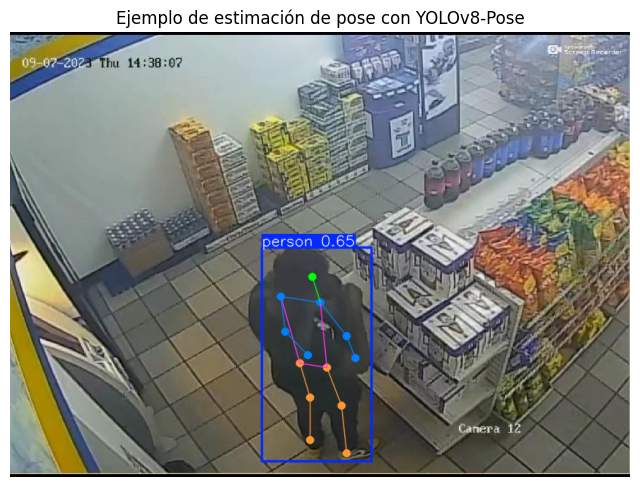

In [36]:
# Buscar una imagen de ejemplo del entrenamiento
example_images = list((DATASET_PATH / 'train' / 'images').glob('*.*'))
example_img = example_images[0]

print('Imagen de ejemplo:', example_img)

# Ejecutar predicción con YOLOv8-Pose
results = pose_model.predict(source=str(example_img), conf=0.25, save=False)

# Mostrar imagen con la pose dibujada
annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title('Ejemplo de estimación de pose con YOLOv8-Pose')
plt.show()

## 7. Funciones para leer etiquetas YOLO

Como cada `.txt` tiene una sola fila, se toma la primera clase encontrada en el archivo.

Ejemplo:

```text
1 0.52 0.41 0.25 0.60
```

La clase sería `1`, es decir, **robo**.


In [37]:
def read_yolo_label(label_path):
    '''Lee la primera clase de un archivo .txt en formato YOLO.'''
    label_path = Path(label_path)
    
    if not label_path.exists():
        return None
    
    content = label_path.read_text().strip().splitlines()
    
    if len(content) == 0:
        return None
    
    first_line = content[0].split()
    class_id = int(first_line[0])
    
    return class_id

## 8. Extraer keypoints normalizados de una imagen

En esta versión ya no se usan coordenadas absolutas del tipo `x=400`, `y=250`, porque eso puede hacer que el clasificador aprenda la posición de la persona en la imagen en vez de su postura.

Se aplica una normalización corporal:

```text
1. Se detectan los 17 keypoints del cuerpo con YOLOv8-Pose.
2. Se calcula un centro corporal aproximado usando hombros y caderas.
3. Cada punto se expresa respecto a ese centro.
4. Se divide entre una escala corporal para que no dependa tanto del tamaño de la persona.
```

Así el modelo aprende mejor relaciones como:

```text
mano cerca de cadera
brazo inclinado
torso inclinado
postura corporal relativa
```

y no solo ubicaciones absolutas dentro de la imagen.

In [38]:
KEYPOINT_NAMES = [
    'nose',
    'left_eye', 'right_eye',
    'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle'
]

# Índices del formato COCO usado por YOLOv8-Pose
KP = {name: i for i, name in enumerate(KEYPOINT_NAMES)}


def _safe_point(keypoints, name):
    """Devuelve el punto [x, y] de un keypoint."""
    return keypoints[KP[name]].astype(float)


def _midpoint(p1, p2):
    return (p1 + p2) / 2.0


def normalize_pose_keypoints(keypoints):
    """
    Normaliza los keypoints respecto al cuerpo.
    Entrada: keypoints con shape (17, 2), coordenadas absolutas en píxeles.
    Salida: diccionario de features normalizadas.
    """
    keypoints = np.asarray(keypoints, dtype=float)

    left_shoulder = _safe_point(keypoints, 'left_shoulder')
    right_shoulder = _safe_point(keypoints, 'right_shoulder')
    left_hip = _safe_point(keypoints, 'left_hip')
    right_hip = _safe_point(keypoints, 'right_hip')

    shoulder_mid = _midpoint(left_shoulder, right_shoulder)
    hip_mid = _midpoint(left_hip, right_hip)

    body_center = _midpoint(shoulder_mid, hip_mid)

    torso_scale = np.linalg.norm(shoulder_mid - hip_mid)
    shoulder_scale = np.linalg.norm(left_shoulder - right_shoulder)
    scale = torso_scale if torso_scale > 1 else shoulder_scale

    if scale <= 1:
        scale = 1.0

    features = {}

    for i, name in enumerate(KEYPOINT_NAMES):
        x, y = keypoints[i]
        features[f'{name}_x_norm'] = (x - body_center[0]) / scale
        features[f'{name}_y_norm'] = (y - body_center[1]) / scale

    pairs = [
        ('left_wrist', 'left_hip'),
        ('right_wrist', 'right_hip'),
        ('left_wrist', 'right_hip'),
        ('right_wrist', 'left_hip'),
        ('left_wrist', 'left_shoulder'),
        ('right_wrist', 'right_shoulder'),
        ('left_wrist', 'right_wrist'),
        ('left_elbow', 'left_hip'),
        ('right_elbow', 'right_hip'),
    ]

    for a, b in pairs:
        pa = _safe_point(keypoints, a)
        pb = _safe_point(keypoints, b)
        features[f'dist_{a}_to_{b}'] = np.linalg.norm(pa - pb) / scale

    features['torso_dx'] = (shoulder_mid[0] - hip_mid[0]) / scale
    features['torso_dy'] = (shoulder_mid[1] - hip_mid[1]) / scale

    return features


def extract_pose_features(image_path, model, conf=0.25):
    """Extrae keypoints normalizados de una imagen usando YOLOv8-Pose."""
    image_path = Path(image_path)
    img = cv2.imread(str(image_path))
    
    if img is None:
        return None
    
    results = model.predict(source=str(image_path), conf=conf, save=False, verbose=False)
    result = results[0]
    
    if result.keypoints is None or len(result.keypoints.xy) == 0:
        return None
    
    keypoints = result.keypoints.xy[0].cpu().numpy()  # shape: (17, 2)
    features = normalize_pose_keypoints(keypoints)
    
    return features

## 9. Construir CSV de poses

Aquí se recorren las imágenes de `train`, `valid` y `test`. Para cada imagen:

1. Se lee su etiqueta YOLO.
2. Se extraen los keypoints con YOLOv8-Pose.
3. Se guarda una fila en un DataFrame.

El resultado será un archivo `.csv` con los puntos corporales y su clase correspondiente.


In [39]:
def build_pose_dataframe(split, model, conf=0.25):
    images_dir = DATASET_PATH / split / 'images'
    labels_dir = DATASET_PATH / split / 'labels'
    
    image_files = sorted(list(images_dir.glob('*.*')))
    rows = []
    skipped_no_label = 0
    skipped_no_pose = 0
    
    for img_path in tqdm(image_files, desc=f'Procesando {split}'):
        label_path = labels_dir / f'{img_path.stem}.txt'
        label = read_yolo_label(label_path)
        
        if label is None:
            skipped_no_label += 1
            continue
        
        features = extract_pose_features(img_path, model, conf=conf)
        
        if features is None:
            skipped_no_pose += 1
            continue
        
        features['image_path'] = str(img_path)
        features['label'] = label
        features['label_name'] = CLASS_NAMES[label]
        features['split'] = split
        
        rows.append(features)
    
    df = pd.DataFrame(rows)
    
    print(f"\nResumen {split}:")
    print('Imágenes procesadas:', len(image_files))
    print('Filas guardadas:', len(df))
    print('Sin etiqueta:', skipped_no_label)
    print('Sin pose detectada:', skipped_no_pose)
    
    return df

In [40]:
# Construir datasets de poses
# Puede demorar algunos minutos dependiendo de tu PC.

train_df = build_pose_dataframe('train', pose_model, conf=0.25)
valid_df = build_pose_dataframe('valid', pose_model, conf=0.25)
test_df = build_pose_dataframe('test', pose_model, conf=0.25)

print('Tamaños:')
print('Train:', train_df.shape)
print('Valid:', valid_df.shape)
print('Test:', test_df.shape)

Procesando train: 100%|██████████| 584/584 [00:24<00:00, 23.83it/s]



Resumen train:
Imágenes procesadas: 584
Filas guardadas: 520
Sin etiqueta: 2
Sin pose detectada: 62


Procesando valid: 100%|██████████| 167/167 [00:06<00:00, 24.23it/s]



Resumen valid:
Imágenes procesadas: 167
Filas guardadas: 151
Sin etiqueta: 0
Sin pose detectada: 16


Procesando test: 100%|██████████| 80/80 [00:03<00:00, 24.62it/s]


Resumen test:
Imágenes procesadas: 80
Filas guardadas: 69
Sin etiqueta: 0
Sin pose detectada: 11
Tamaños:
Train: (520, 49)
Valid: (151, 49)
Test: (69, 49)


In [41]:
# Guardar CSVs para reutilizarlos sin volver a ejecutar YOLO Pose
train_df.to_csv('poses_train.csv', index=False)
valid_df.to_csv('poses_valid.csv', index=False)
test_df.to_csv('poses_test.csv', index=False)

print('CSVs guardados correctamente')

CSVs guardados correctamente


## 10. Explorar datos generados

Revisamos cómo quedó el CSV y la distribución de clases.


In [42]:
train_df.head()

,nose_x_norm,nose_y_norm,left_eye_x_norm,left_eye_y_norm,right_eye_x_norm,right_eye_y_norm,left_ear_x_norm,left_ear_y_norm,right_ear_x_norm,right_ear_y_norm,...,dist_right_wrist_to_right_shoulder,dist_left_wrist_to_right_wrist,dist_left_elbow_to_left_hip,dist_right_elbow_to_right_hip,torso_dx,torso_dy,image_path,label,label_name,split
0,0.182337,-0.803080,0.140167,-0.880606,0.162723,-0.868128,-0.178750,-0.883904,0.084946,-0.837035,...,0.979434,0.717314,0.513344,0.559171,-0.190697,-0.981649,dataset\train\images\aahil_1_mp4-101_jpg.rf.39...,0,normal,train
1,0.230620,-0.840089,0.191253,-0.917017,0.191743,-0.899811,-0.104581,-0.908725,0.044393,-0.850433,...,0.990973,0.301108,0.540806,0.543450,-0.180318,-0.983608,dataset\train\images\aahil_1_mp4-102_jpg.rf.0e...,0,normal,train
2,0.217132,-0.810044,0.179639,-0.893115,0.174958,-0.873291,-0.120808,-0.902058,0.038676,-0.836891,...,0.963677,0.410377,0.525594,0.571264,-0.183267,-0.983063,dataset\train\images\aahil_1_mp4-103_jpg.rf.64...,0,normal,train
3,0.146134,-0.806036,0.127593,-0.891497,0.061490,-0.854664,0.038400,-0.905098,-0.160886,-0.818582,...,1.087848,0.373200,0.639044,0.452927,-0.137051,-0.990564,dataset\train\images\aahil_1_mp4-104_jpg.rf.1b...,0,normal,train
4,0.007073,-0.764185,-0.015170,-0.825962,-0.007763,-0.809240,-0.177230,-0.835486,-0.033072,-0.793320,...,1.049486,0.221936,0.533804,0.493592,-0.149178,-0.988810,dataset\train\images\aahil_1_mp4-106_jpg.rf.c1...,0,normal,train


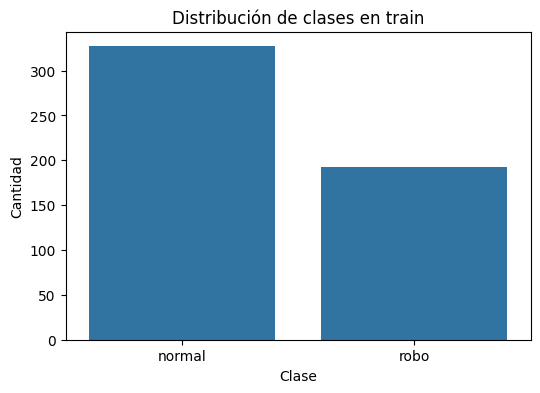

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='label_name')
plt.title('Distribución de clases en train')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

## 11. Preparar datos para entrenamiento

Ahora las características usadas para entrenar ya no son coordenadas absolutas. Se usan:

- Keypoints normalizados respecto al cuerpo.
- Distancias relativas entre muñecas, caderas, hombros y codos.
- Señales simples de inclinación del torso.

Esto ayuda a que el clasificador no dependa tanto de si la persona aparece más a la izquierda, derecha, cerca o lejos de la cámara.

In [44]:
exclude_cols = ['image_path', 'label', 'label_name', 'split']

feature_cols = [col for col in train_df.columns if col not in exclude_cols]

X_train = train_df[feature_cols]
y_train = train_df['label']

X_valid = valid_df[feature_cols]
y_valid = valid_df['label']

X_test = test_df[feature_cols]
y_test = test_df['label']

print('Cantidad de características:', len(feature_cols))
print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)
print('X_test:', X_test.shape)
print('Primeras características:')
print(feature_cols[:10])

Cantidad de características: 45
X_train: (520, 45)
X_valid: (151, 45)
X_test: (69, 45)
Primeras características:
['nose_x_norm', 'nose_y_norm', 'left_eye_x_norm', 'left_eye_y_norm', 'right_eye_x_norm', 'right_eye_y_norm', 'left_ear_x_norm', 'left_ear_y_norm', 'right_ear_x_norm', 'right_ear_y_norm']


## 12. Entrenar clasificador SVM

En esta versión se utiliza un clasificador **SVM** con kernel RBF.  
La idea es comparar si, usando keypoints normalizados, el modelo deja de sesgarse tanto hacia una sola clase.

El flujo es:

```text
Imagen → YOLOv8-Pose → keypoints normalizados → SVM → normal / robo
```

In [45]:
svm_clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    ))
])

svm_clf.fit(X_train, y_train)

print('Clasificador SVM entrenado correctamente con keypoints normalizados')

Clasificador SVM entrenado correctamente con keypoints normalizados


## 13. Evaluación en validación

Primero se evalúa en `valid`, que sirve para revisar el comportamiento del modelo antes de probarlo en test.


In [46]:
y_valid_pred = svm_clf.predict(X_valid)

print('Accuracy valid:', accuracy_score(y_valid, y_valid_pred))
print('Reporte de clasificación:')
print(classification_report(y_valid, y_valid_pred, target_names=CLASS_NAMES))

Accuracy valid: 0.8874172185430463
Reporte de clasificación:
              precision    recall  f1-score   support

      normal       0.96      0.84      0.90        88
        robo       0.81      0.95      0.88        63

    accuracy                           0.89       151
   macro avg       0.89      0.90      0.89       151
weighted avg       0.90      0.89      0.89       151



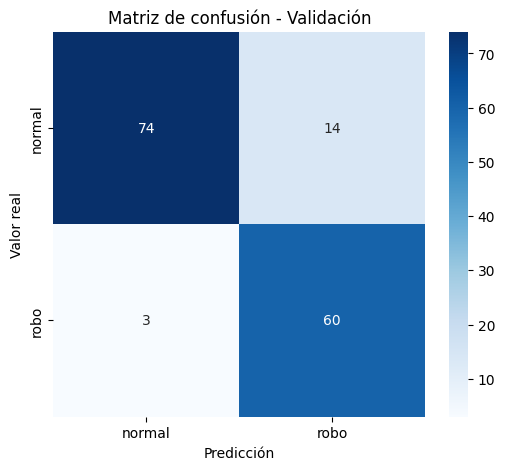

In [47]:
cm_valid = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_valid, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de confusión - Validación')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

## 14. Evaluación final en test

Ahora se evalúa en el conjunto `test`, que representa la prueba final del experimento.


In [48]:
y_test_pred = svm_clf.predict(X_test)

print('Accuracy test:', accuracy_score(y_test, y_test_pred))
print('Reporte de clasificación:')
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES))

Accuracy test: 0.8695652173913043
Reporte de clasificación:
              precision    recall  f1-score   support

      normal       0.92      0.85      0.88        39
        robo       0.82      0.90      0.86        30

    accuracy                           0.87        69
   macro avg       0.87      0.87      0.87        69
weighted avg       0.87      0.87      0.87        69



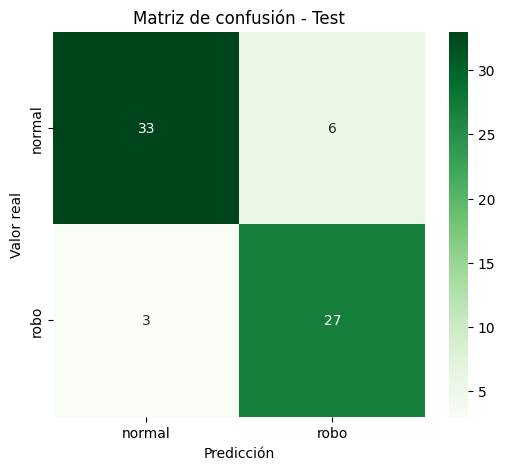

In [49]:
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de confusión - Test')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

## 15. Probar una imagen individual

Esta función permite probar una imagen nueva. Primero extrae la pose y luego usa el clasificador para predecir si es normal o robo.


In [50]:
def predict_image(image_path, pose_model, clf, conf=0.25):
    image_path = Path(image_path)
    features = extract_pose_features(image_path, pose_model, conf=conf)
    
    if features is None:
        print('No se detectó una pose humana en la imagen.')
        return None
    
    X = pd.DataFrame([features])[feature_cols]
    pred = svm_clf.predict(X)[0]
    proba = svm_svm_clf.predict_proba(X)[0]
    
    print('Imagen:', image_path)
    print('Predicción:', CLASS_NAMES[pred])
    print('Probabilidades:')
    
    for class_name, p in zip(CLASS_NAMES, proba):
        print(f'  {class_name}: {p:.4f}')
    
    # Mostrar pose en la imagen
    results = pose_model.predict(source=str(image_path), conf=conf, save=False, verbose=False)
    annotated = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(8,8))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title(f'Predicción: {CLASS_NAMES[pred]}')
    plt.show()
    
    return pred, proba

## 16. Guardar modelo entrenado

Se guarda el clasificador SVM entrenado con keypoints normalizados para usarlo luego en imágenes o videos nuevos.

In [51]:
joblib.dump(svm_clf, 'clasificador_pose_svm_normalizado.pkl')
print('Modelo guardado como clasificador_pose_svm_normalizado.pkl')

Modelo guardado como clasificador_pose_svm_normalizado.pkl


---

## 17. Prueba

In [1]:
import cv2
import joblib
import pandas as pd
from collections import deque
from ultralytics import YOLO

pose_model = YOLO("yolov8n-pose.pt")
clf_video = joblib.load("clasificador_pose_svm_normalizado.pkl")

video_path = "video2.mp4"

cap = cv2.VideoCapture(video_path)

# Filtro temporal para que no cambie por un solo frame aislado
historial_robo = deque(maxlen=10)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = pose_model.predict(frame, conf=0.25, verbose=False)
    result = results[0]

    annotated_frame = result.plot()
    label_text = "SIN POSE"
    color = (255, 255, 255)
    conf_text = ""

    if result.keypoints is not None and len(result.keypoints.xy) > 0:
        keypoints = result.keypoints.xy[0].cpu().numpy()

        features = normalize_pose_keypoints(keypoints)
        X_video = pd.DataFrame([features])[feature_cols]

        proba = clf_video.predict_proba(X_video)[0]
        prob_normal = proba[0]
        prob_robo = proba[1]

        # Predicción por frame
        pred_frame = 1 if prob_robo >= 0.60 else 0
        historial_robo.append(pred_frame)

        # Decisión temporal: robo si aparece en varios frames recientes
        robos_recientes = sum(historial_robo)

        if robos_recientes >= 6:
            label_text = "ROBO"
            color = (0, 0, 255)
        else:
            label_text = "NORMAL"
            color = (0, 255, 0)

        conf_text = f"Robo:{prob_robo:.2f} Normal:{prob_normal:.2f}"

    cv2.putText(
        annotated_frame,
        f"{label_text} {conf_text}",
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        color,
        3
    )

    cv2.imshow("YOLOv8 Pose + SVM Normalizado", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

NameError: name 'normalize_pose_keypoints' is not defined

## 17. Interpretación para el informe

Puedes usar este texto como base para explicar la mejora realizada:

> En este experimento se evaluó un enfoque basado en YOLOv8-Pose y un clasificador SVM para identificar actividades sospechosas. Inicialmente, el uso de coordenadas corporales directas podía generar problemas, ya que el modelo podía aprender la posición o el tamaño de la persona dentro de la imagen, en lugar de analizar la postura corporal. Por ello, se aplicó una normalización de keypoints, tomando como referencia el centro del cuerpo y una escala aproximada del torso.
>
> Esta normalización permitió representar la postura de forma relativa, reduciendo la dependencia de la ubicación de la persona en la imagen. Además, se añadieron características derivadas, como distancias entre muñecas, caderas, hombros y codos, con el objetivo de capturar mejor relaciones corporales asociadas a acciones sospechosas.
>
> El flujo experimental quedó compuesto por tres etapas principales: detección de pose con YOLOv8-Pose, extracción de keypoints normalizados y clasificación mediante SVM. Esta propuesta permite analizar si la postura corporal aporta información útil para diferenciar entre comportamientos normales y posibles acciones de robo.

---

## 18. Limitaciones del experimento

> Aunque la normalización de keypoints mejora la representación de la postura, el experimento todavía se basa en imágenes o frames individuales. Por ello, no analiza completamente la secuencia temporal de la acción, como el movimiento de la mano hacia una vitrina y luego hacia una bolsa. Además, algunas acciones de robo pueden depender de objetos o contexto visual que no están incluidos en los keypoints corporales.
>
> Por esta razón, este experimento debe interpretarse como una aproximación basada en postura corporal, no como una solución final de reconocimiento de acciones complejas.

---

## 19. Conclusión experimental

> La incorporación de keypoints normalizados permitió mejorar el planteamiento del experimento, ya que el clasificador SVM trabaja con información corporal relativa y no solamente con coordenadas absolutas. Esto hace que el modelo sea más coherente para analizar posturas relacionadas con actividades sospechosas. Sin embargo, para escenarios reales, se recomienda complementar este enfoque con análisis temporal, seguimiento de personas e información contextual del entorno.